<h1>My Deep Learning Project: Loan Default Prediction using Artificial Neural Networks (ANN) in TensorFlow / Keras</h1>

---

### Project Overview
In this project, I am building an <b>Artificial Neural Network (ANN)</b> in <b>TensorFlow / Keras</b> to predict whether a loan applicant will default on their credit payment!

### Key Concepts Covered:
- <b>✅ TensorFlow / Keras Framework</b>: <code>tf.keras.Sequential</code>, <code>Dense</code>, <code>Dropout</code>, <code>BatchNormalization</code>.
- <b>✅ Feature Scaling</b>: Standardizing continuous tabular features with <code>StandardScaler</code>.
- <b>✅ Class Imbalance Handling</b>: Balancing minority default cases using <code>SMOTE</code>.
- <b>✅ Optimization & Regularization</b>: <code>tf.keras.losses.BinaryCrossentropy</code>, <code>tf.keras.optimizers.Adam</code>, Dropout, and Batch Normalization.
- <b>✅ Threshold Tuning & Metrics</b>: Loss/Accuracy curves, F1-score optimization, Seaborn Confusion Matrix.

---

<h2>Step 1: Importing Libraries & GPU Setup</h2>

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Set random seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
TensorFlow Version: 2.15.0
Libraries imported successfully!


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'



<h2>Step 2: Generating Synthetic Loan Dataset</h2>

In [3]:
# ======================================================
# STEP 2: CREATING LOAN DEFAULT DATASET
# ======================================================
print("--- STEP 2: CREATING LOAN DATASET ---")

np.random.seed(42)
n_samples = 1200

income = np.random.normal(55000, 15000, n_samples)
loan_amount = np.random.normal(20000, 8000, n_samples)
credit_score = np.random.normal(650, 70, n_samples)
age = np.random.randint(21, 65, n_samples)
months_employed = np.random.randint(1, 240, n_samples)

# Default risk probability formula
log_odds = -2.0 + (loan_amount / income) * 2.5 - (credit_score - 600) / 100 - (months_employed / 120)
prob = 1 / (1 + np.exp(-log_odds))
target = (prob > 0.45).astype(int)

df = pd.DataFrame({
    'Income': income,
    'LoanAmount': loan_amount,
    'CreditScore': credit_score,
    'Age': age,
    'MonthsEmployed': months_employed,
    'Default': target
})

print(f"Dataset Shape: {df.shape}")
print("Target Class Distribution:")
print(df['Default'].value_counts())
print(df.head())

--- STEP 2: CREATING LOAN DATASET ---
Dataset Shape: (1200, 6)
Target Class Distribution:
Default
0    1178
1      22
Name: count, dtype: int64
         Income    LoanAmount  CreditScore  Age  MonthsEmployed  Default
0  62450.712295  21001.796021   599.478371   31              78        0
1  52926.035482  16564.755671   662.377461   55              70        0
2  64715.328072  20978.380024   611.732394   57             178        0
3  77845.447846  24346.384232   630.984142   62             101        0
4  51487.699379  20390.880563   767.141646   33             160        0


<h2>Step 3: Train / Validation / Test Split, Scaling & SMOTE</h2>

In [4]:
# ======================================================
# STEP 3: PREPROCESSING & SMOTE
# ======================================================
print("--- STEP 3: DATA PREPROCESSING ---")

X = df.drop(columns=['Default'])
y = df['Default']

# 80/20 Train-Val / Test split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Train Shape after SMOTE: {X_train_res.shape}, Class Balance: {np.bincount(y_train_res)}")
print(f"Val Shape: {X_val_scaled.shape}, Test Shape: {X_test_scaled.shape}")

--- STEP 3: DATA PREPROCESSING ---
Train Shape after SMOTE: (1412, 5), Class Balance: [706 706]
Val Shape: (240, 5), Test Shape: (240, 5)


<h2>Step 4: Building TensorFlow / Keras ANN Architecture</h2>

In [5]:
# ======================================================
# STEP 4: TENSORFLOW ANN MODEL DEFINITION
# ======================================================
print("--- STEP 4: BUILDING TENSORFLOW ANN ---")

model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

model_ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model_ann.summary())

--- STEP 4: BUILDING TENSORFLOW ANN ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                384       
                                                                 
 batch_normalization (Batch  (None, 64)                256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dropout_1 (Drop

<h2>Step 5: Model Training & Learning Curves</h2>

--- STEP 5: TRAINING ANN MODEL ---
Epoch 1/25

45/45 [==============================] - 3s 13ms/step - loss: 0.3622 - accuracy: 0.8421 - val_loss: 0.5797 - val_accuracy: 0.7792
Epoch 2/25

45/45 [==============================] - 0s 6ms/step - loss: 0.1685 - accuracy: 0.9441 - val_loss: 0.4091 - val_accuracy: 0.8792
Epoch 3/25

45/45 [==============================] - 0s 5ms/step - loss: 0.1353 - accuracy: 0.9582 - val_loss: 0.2761 - val_accuracy: 0.9250
Epoch 4/25

45/45 [==============================] - 0s 5ms/step - loss: 0.1137 - accuracy: 0.9646 - val_loss: 0.1881 - val_accuracy: 0.9417
Epoch 5/25

45/45 [==============================] - 0s 6ms/step - loss: 0.0953 - accuracy: 0.9717 - val_loss: 0.1381 - val_accuracy: 0.9542
Epoch 6/25

45/45 [==============================] - 0s 6ms/step - loss: 0.0954 - accuracy: 0.9688 - val_loss: 0.1127 - val_accuracy: 0.9583
Epoch 7/25

45/45 [==============================] - 0s 6ms/step - loss: 0.0829 - accuracy: 0.9703 - val_loss: 0.0963 

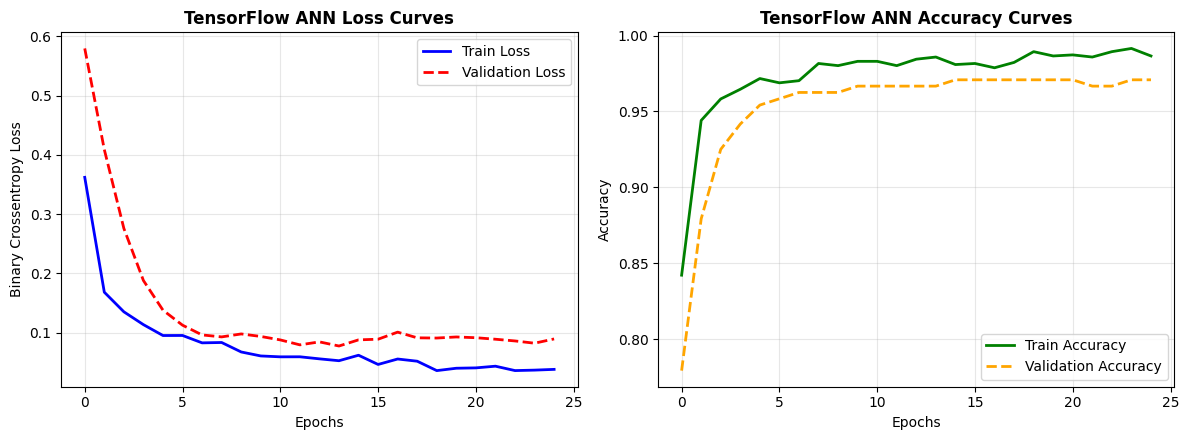

In [6]:
# ======================================================
# STEP 5: TRAINING TENSORFLOW ANN MODEL
# ======================================================
print("--- STEP 5: TRAINING ANN MODEL ---")

history_ann = model_ann.fit(
    X_train_res, y_train_res,
    validation_data=(X_val_scaled, y_val),
    epochs=25,
    batch_size=32,
    verbose=1
)

# Plot Loss & Accuracy Curves
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history_ann.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history_ann.history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title("TensorFlow ANN Loss Curves", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_ann.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
plt.title("TensorFlow ANN Accuracy Curves", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h2>Step 6: Threshold Tuning & Test Evaluation</h2>

--- STEP 6: THRESHOLD TUNING & TEST EVALUATION ---

8/8 [==============================] - 0s 2ms/step
Optimal Decision Threshold: 0.75 (Val F1-Score: 0.5714)

8/8 [==============================] - 0s 3ms/step
TENSORFLOW ANN TEST EVALUATION METRICS
  • Accuracy:  0.9792
  • Precision: 0.4000
  • Recall:    0.5000
  • F1-Score:  0.4444
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       236
           1       0.40      0.50      0.44         4

    accuracy                           0.98       240
   macro avg       0.70      0.74      0.72       240
weighted avg       0.98      0.98      0.98       240



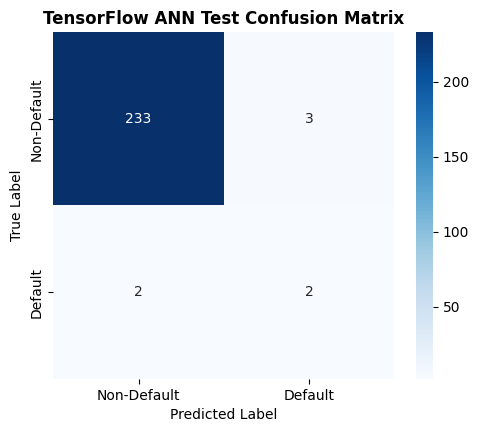

In [7]:
# ======================================================
# STEP 6: THRESHOLD TUNING & METRICS
# ======================================================
print("--- STEP 6: THRESHOLD TUNING & TEST EVALUATION ---")

val_probs = model_ann.predict(X_val_scaled).ravel()
best_thresh = 0.5
best_f1 = 0.0

for thresh in np.arange(0.1, 0.9, 0.05):
    preds = (val_probs >= thresh).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Optimal Decision Threshold: {best_thresh:.2f} (Val F1-Score: {best_f1:.4f})")

# Evaluate on Test Set
test_probs = model_ann.predict(X_test_scaled).ravel()
test_preds = (test_probs >= best_thresh).astype(int)

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds, zero_division=0)
rec = recall_score(y_test, test_preds, zero_division=0)
f1 = f1_score(y_test, test_preds, zero_division=0)

print("="*55)
print("TENSORFLOW ANN TEST EVALUATION METRICS")
print("="*55)
print(f"  • Accuracy:  {acc:.4f}")
print(f"  • Precision: {prec:.4f}")
print(f"  • Recall:    {rec:.4f}")
print(f"  • F1-Score:  {f1:.4f}")
print("="*55)
print("Classification Report:")
print(classification_report(y_test, test_preds))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Default', 'Default'], yticklabels=['Non-Default', 'Default'])
plt.title("TensorFlow ANN Test Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()